[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sear-labs/energy-system-modeling/blob/main/notebooks/p2_demand/05_representative_days.ipynb)
# From a smart meter to three representative days
## REE 4301 / IE 5300 - Energy Systems Modeling

A model runs on 8,760 hours. You cannot reason about 8,760 hours and neither can a reader, so almost every study in this field compresses the year into a handful of representative days.

**That compression is a modelling assumption, and it is only honest when you show it reconciles.** Three days that miss the annual total by 30% are not representative of anything. The reconciliation is the deliverable here, not the plot.


In [1]:
# --- setup: generated by tools/sync_setup_cells.py -- do not edit here, edit that
# The same cell in every notebook in this series. It installs what Colab does
# not have, fetches the repository so that data/ and src/ are present, and moves
# into this notebook's own folder so the relative paths below resolve.
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/sear-labs/energy-system-modeling"
REPO_NAME = REPO_URL.rstrip("/").split("/")[-1]
NOTEBOOK_DIR = "notebooks/p2_demand"

# Pinned, per Part 1 rule 3: an unpinned install will one day pull a major
# version with a changed API and either break or silently alter the answer.
PINS = []

if "google.colab" in sys.modules:
    if PINS:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *PINS], check=True)
    # An ABSOLUTE base, so re-running this cell is safe. Colab's "Run all" is
    # commonly run twice, and a relative check would look for the clone inside
    # the folder it had already moved into -- cloning a second copy nested one
    # level down, then working from the wrong one.
    BASE = Path("/content") if Path("/content").is_dir() else Path.home()
    REPO_DIR = BASE / REPO_NAME
    if not REPO_DIR.exists():
        cloned = subprocess.run(
            ["git", "clone", "--depth", "1", REPO_URL, str(REPO_DIR)],
            capture_output=True, text=True)
        if cloned.returncode != 0:
            raise SystemExit(
                "Could not clone " + REPO_URL + "\n"
                + (cloned.stderr or "").strip() + "\n\n"
                "If that says 'not found', the repository is still private.\n"
                "A raw file URL fails the same way, so there is no way around\n"
                "it: it has to be public before a student can run this.")
    os.chdir(REPO_DIR / NOTEBOOK_DIR)
elif Path.cwd().name != Path(NOTEBOOK_DIR).name:
    raise SystemExit(
        "Run this notebook from its own folder (" + NOTEBOOK_DIR + "),\n"
        "so that ../../src and ../../data resolve.")

sys.path.insert(0, str(Path.cwd().parents[1] / "src"))
print("working directory:", Path.cwd().name)

# --- end generated setup; the notebook's own imports follow ---


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


working directory: p2_demand


---
## Step 1 - Load your own interval data

Point `DEMAND_CSV_PATH` at your utility export - an ERCOT-style file with `USAGE_DATE`, `USAGE_START_TIME` and `USAGE_KWH` columns.

**If that file is not next to the notebook** - which it will not be the first time you open this - the cell falls back to a synthetic year so the rest runs. It will say so loudly. **A synthetic profile is not an acceptable submission**; upload your own export before you write anything up.


In [2]:
DEMAND_CSV_PATH = 'IntervalData.csv'   # <-- your own export


def load_interval(path):
    """15-minute ERCOT-style export -> hourly mean kW on a real index."""
    raw = pd.read_csv(path)
    ts = pd.to_datetime(raw['USAGE_DATE'] + ' ' + raw['USAGE_START_TIME'],
                        format='%m/%d/%Y %H:%M')
    kwh15 = raw.set_index(ts)['USAGE_KWH']
    return kwh15.resample('1h').sum() * 4


def synthetic_year():
    """Stand-in only: evening peak, morning bump, summer cooling."""
    idx = pd.date_range('2025-01-01', periods=8760, freq='1h')
    hour, doy = idx.hour.to_numpy(), idx.dayofyear.to_numpy()
    shape = (0.9 + 0.45 * np.exp(-((hour - 19) ** 2) / 6.0)
             + 0.20 * np.exp(-((hour - 7) ** 2) / 4.0))
    cooling = 1 + 0.55 * np.clip(np.sin(np.pi * (doy - 100) / 240), 0, 1)
    rng = np.random.default_rng(0)
    kw = 1.4 * shape * cooling * rng.normal(1.0, 0.05, len(idx))
    return pd.Series(np.clip(kw, 0.15, None), index=idx)


try:
    demand_kw = load_interval(DEMAND_CSV_PATH)
    IS_REAL = True
    print(f'loaded {DEMAND_CSV_PATH}: {len(demand_kw):,} hourly points')
except FileNotFoundError:
    demand_kw = synthetic_year()
    IS_REAL = False
    print('=' * 66)
    print(f'NO FILE NAMED {DEMAND_CSV_PATH} - using a SYNTHETIC year.')
    print('The notebook will run, but this is not your data and it is')
    print('not an acceptable submission. Upload your export and re-run.')
    print('=' * 66)

print(f'{demand_kw.index[0]:%Y-%m-%d} to {demand_kw.index[-1]:%Y-%m-%d}')
print(f'peak {demand_kw.max():.2f} kW   mean {demand_kw.mean():.2f} kW')


NO FILE NAMED IntervalData.csv - using a SYNTHETIC year.
The notebook will run, but this is not your data and it is
not an acceptable submission. Upload your export and re-run.
2025-01-01 to 2025-12-31
peak 3.32 kW   mean 1.74 kW


## Step 2 - Look at it before you compress it

Plot the year, then plot one week. **Say in one sentence what shape it has and why** - occupancy, weather, a process schedule. If you cannot, you are not ready to choose representative days, because you do not yet know what they have to represent.


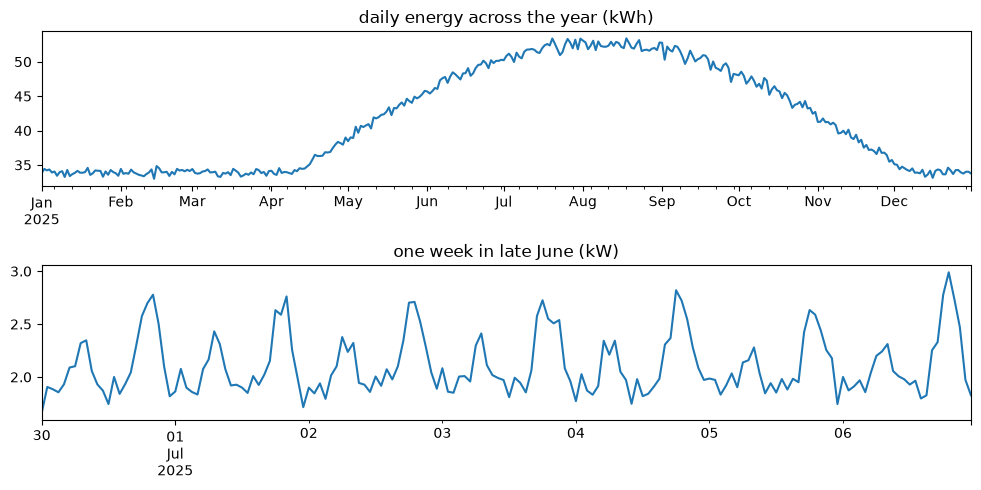

annual total 15,251 kWh
highest day  53 kWh on 18 Aug
lowest day   33 kWh on 14 Feb


In [3]:
daily_kwh = demand_kw.resample('1D').sum()

fig, ax = plt.subplots(2, 1, figsize=(10, 5))
daily_kwh.plot(ax=ax[0], title='daily energy across the year (kWh)')
demand_kw.iloc[24 * 180:24 * 187].plot(
    ax=ax[1], title='one week in late June (kW)')
plt.tight_layout(); plt.show()

print(f'annual total {daily_kwh.sum():,.0f} kWh')
print(f'highest day  {daily_kwh.max():,.0f} kWh on {daily_kwh.idxmax():%d %b}')
print(f'lowest day   {daily_kwh.min():,.0f} kWh on {daily_kwh.idxmin():%d %b}')


---
## Step 3 - Choose three days, and say how you chose them

Any defensible rule is acceptable **provided you state it**. The rule below sorts the year by daily energy and takes days at the one-sixth, one-half and five-sixths points - so each stands for a third of the year and none of them is an outlier.

Alternatives worth considering, and worth defending if you use them: peak / average / minimum; one day per season; or a clustering on the hourly shape rather than the daily total.

**Every representative day needs a weight** - how many real days it stands for. Without weights you have three days, not a year.


In [4]:
order = daily_kwh.sort_values()
n = len(order)

picks = [order.index[n // 6], order.index[n // 2], order.index[5 * n // 6]]
weights = [n // 3, n - 2 * (n // 3), n // 3]

rep = pd.DataFrame({
    'date': [d.strftime('%d %b') for d in picks],
    'kWh that day': [round(daily_kwh[d]) for d in picks],
    'stands for (days)': weights,
})
print(rep.to_string(index=False))
print(f'\nweights sum to {sum(weights)} days')


  date  kWh that day  stands for (days)
08 Mar            34                121
08 Nov            41                123
06 Jul            51                121

weights sum to 365 days


---
## Step 4 - Reconcile. This is the graded part

Multiply each representative day by its weight, add them up, and compare against the measured annual total.

**Predict first.** Will your three days over- or under-state the year, and why? The direction is more interesting than the magnitude.


In [5]:
estimate = sum(daily_kwh[d] * w for d, w in zip(picks, weights))
actual = daily_kwh.sum()
error = estimate / actual - 1

print(f'three weighted days {estimate:>12,.0f} kWh')
print(f'measured year       {actual:>12,.0f} kWh')
print(f'error               {error:>12.1%}')


three weighted days       15,331 kWh
measured year             15,251 kWh
error                       0.5%


**A few percent is normal and fine.** Say so and move on.

**Ten percent or more means the day selection is wrong**, not that the data is. The usual cause is that the chosen days miss a shape rather than a level - a facility with a sharp summer peak and a flat winter is badly served by three days picked on total energy alone, because two of them look identical.

> **Exercise 4.1.** Re-pick using peak / average / minimum instead. Does the error get better or worse, and does that tell you the rule is better or just luckier? Say how you would tell the difference.
>
> **Exercise 4.2.** Report the error **and keep it in your write-up.** A representative-day study that does not state its reconciliation error is not a study, it is an assertion.


---
## Step 5 - Degree days

Regress daily energy on heating and cooling degree days. The base temperature is a choice - state it and say how you chose it.

Without a weather file this step uses a proxy built from day of year. **Replace it with real degree days from NOAA for your own station** before you report anything; the proxy is here so the mechanics are visible.


In [6]:
# Proxy only. Substitute real HDD/CDD for your weather station.
doy = daily_kwh.index.dayofyear.to_numpy()
temp_f = 62 + 22 * np.sin(np.pi * (doy - 110) / 182.5)

BASE = 65.0     # degF. State yours and justify it.
cdd = np.clip(temp_f - BASE, 0, None)
hdd = np.clip(BASE - temp_f, 0, None)

X = np.column_stack([np.ones_like(cdd), cdd, hdd])
beta, *_ = np.linalg.lstsq(X, daily_kwh.values, rcond=None)
pred = X @ beta
ss_res = ((daily_kwh.values - pred) ** 2).sum()
ss_tot = ((daily_kwh.values - daily_kwh.mean()) ** 2).sum()

print(f'base temperature     {BASE:.0f} F')
print(f'baseline load        {beta[0]:8.1f} kWh/day')
print(f'per cooling degree   {beta[1]:8.1f} kWh')
print(f'per heating degree   {beta[2]:8.1f} kWh')
print(f'R-squared            {1 - ss_res / ss_tot:8.3f}')


base temperature     65 F
baseline load            41.6 kWh/day
per cooling degree        0.6 kWh
per heating degree       -0.3 kWh
R-squared               0.877


> **Exercise 5.1.** State how much of the variation the regression explains, and name one thing driving the rest. Occupancy, a production schedule and day-of-week effects are the usual suspects - which applies to your site?
>
> **Exercise 5.2.** Try three base temperatures and report which fits best. The base temperature is not a physical constant; it is a property of the building.


---

*Before class: these representative days came from one site's meter. A region's load curve is far smoother. Which of your clusters would survive that smoothing, and which exists only because one building does one thing at a time?*



In [7]:
top4 = demand_kw.nlargest(4)
print('your four highest hours:')
for t, v in top4.items():
    print(f'   {t:%d %b %H:%M}   {v:.2f} kW')
print()
summer = top4.index.month.isin([6, 7, 8, 9]).sum()
print(f'{summer} of your 4 peak hours fall in June-September,')
print('which is when ERCOT sets 4CP. Would yours have coincided with the')
print('system peak, or only with your own?')


your four highest hours:
   11 Aug 19:00   3.32 kW
   14 Aug 20:00   3.21 kW
   19 Aug 19:00   3.21 kW
   23 Aug 18:00   3.13 kW

4 of your 4 peak hours fall in June-September,
which is when ERCOT sets 4CP. Would yours have coincided with the
system peak, or only with your own?


> **Exercise 6.1.** Look up the actual 4CP intervals for the most recent year and check your load in them. If your peak and the system's do not coincide, you may already be paying less than you think - or have more headroom to shift than you think.

### Sources
- Your own utility interval export. In ERCOT territory: Smart Meter Texas.
- NOAA / NCEI for real heating and cooling degree days at your station.
- ERCOT and your utility's published 4CP guidance for the transmission charge mechanism.
